# Exercise 5: Regression II

In [1]:
import pandas as pd

df = pd.read_csv("data/credit_default.csv")
df.head()

# Part 1 — Analyze early-career urban borrowers with logistic regression

### Task 1.1 — Prepare the subset

Create a filtered dataset that contains only customers from early-career
urban borrowers.

## Solution

In [3]:
df_A = df[df["customer_category"] == "early_career_urban"]

### Task 1.2 — Estimate the model

Estimate a logistic regression model to predict credit default.

## Solution

*Note*: You will initially encounter a `ConvergenceWarning`, indicating
that the maximum likelihood estimation has not fully converged. To
address this, increase the `max_iter` parameter to give the optimization
algorithm sufficient iterations to converge.

In [5]:
from sklearn.linear_model import LogisticRegression

y = df_A["default"]
X = df_A.drop(columns=["default", "customer_category"])

model = LogisticRegression(max_iter=1000)
model.fit(X, y)

model.intercept_, model.coef_

(array([-0.89628046]),
 array([[-5.17141355e-04,  4.43772771e-02,  1.06127022e+00,
          1.15564749e+00, -1.62449875e-02]]))

### Task 1.3 — Interpret the model

Interpret the coefficients in substantive terms:

## Solution

In [6]:
import pandas as pd

coef_df = pd.DataFrame({"feature": X.columns, "coefficient": model.coef_[0]})

coef_df

- Which variables increase the likelihood of default?

> **Solution**
>
> Variables with positive coefficients increase default risk.  
> In this model, the strongest positive effects are:
>
> - `credit_utilization` (1.16) → strongest increase in default risk
> - `missed_payments_12m` (1.06) → substantial increase in default risk

- Which variables decrease it?

> **Solution**
>
> Variables with negative coefficients decrease default risk.  
> In this model:
>
> - `debt_to_income` (0.04) → moderate decrease in default risk
> - `months_with_company` (-0.02) → small decrease
> - `income` (-0.00) → very small (negligible) decrease

- Which variable appears to have the strongest relationship with
  default?

> **Solution**
>
> The variable with the largest absolute coefficient has the strongest
> relationship.  
> Here, `credit_utilization` (\|1.16\|) is the most influential
> predictor, closely followed by `missed_payments_12m` (\|1.06\|).

### Task 1.4 — From coefficients to classification

Explain how the model moves from:

- a linear combination of predictors
- to a predicted probability
- to a classification as default / non-default

## Solution

Steps:

1.  Linear combination (log-odds)
2.  Logistic transformation → probability
3.  Threshold (e.g., 0.5) → class label

In [7]:
# Example for one observation
z = model.intercept_[0] + (X.iloc[0] * model.coef_[0]).sum()

import numpy as np

p = 1 / (1 + np.exp(-z))

# Apply threshold
y_class = int(p >= 0.5)

p, y_class

(np.float64(0.4677867020758892), 0)

With a predicted probability of 46.8%, the observation would be
classified as “no default” under a 50% threshold.



# Part 2 — Probabilities and thresholds

### Task 2.1 — Understanding outputs

Run the code and answer the following questions:

In [8]:
y_prob = model.predict_proba(X)[:, 1]
y_pred = model.predict(X)
y_prob[:5], y_pred[:5]

- What is the difference between `y_prob` and `y_pred`?
- Why does `predict_proba` return two columns?

## Solution

In [9]:
y_prob = model.predict_proba(X)[:, 1]
y_pred = model.predict(X)
y_prob[:5], y_pred[:5]

(array([0.4677867 , 0.60611356, 0.95816943, 0.14730322, 0.7064933 ]),
 array([0, 1, 1, 0, 1]))

- `y_prob`: probabilities for class 1 (default)
- `y_pred`: binary predictions based on threshold (`0.5` per default)

In [10]:
model.predict_proba(X[:5])

array([[0.5322133 , 0.4677867 ],
       [0.39388644, 0.60611356],
       [0.04183057, 0.95816943],
       [0.85269678, 0.14730322],
       [0.2935067 , 0.7064933 ]])

- Column 0 → P(no default)
- Column 1 → P(default)

### Task 2.2 — Manual thresholding

## Solution

Manually adapting the threshold `t` should show:

- Lower threshold → more customers flagged as risky
- Higher threshold → fewer customers flagged as risky

For top 20% risk:

In [14]:
threshold_risky = np.quantile(y_prob, 0.8)
y_pred_20 = (y_prob >= threshold_risky).astype(int)
threshold_risky, y_pred_20.sum()

(np.float64(0.6416442644835957), np.int64(39))

- Selects customers with the highest predicted probabilities in the
  `y_pred_20` vector

For safest 20%:

In [15]:
threshold_safe = np.quantile(y_prob, 0.2)
y_pred_80 = (y_prob >= threshold_safe).astype(int)
threshold_safe, y_pred_80.sum()

(np.float64(0.1675110069415143), np.int64(154))

- Identifies customers with very low predicted risk in the `y_pred_80`
  vector

Low risk customers could be selected as follows:

In [16]:
safe_customers = df_A[y_pred_80 == 0]

safe_customers.head()

# Part 3 — Confusion matrix and metrics

### Task 3.1 — Interpret the matrix

## Solution

In [18]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y, y_pred)
cm

array([[94, 19],
       [36, 44]])

- TP: 44
- TN: 94
- FP: 19
- FN: 36

*Note: the `ravel()` function can be helpful to access the individual
values:*

In [19]:
tn, fp, fn, tp = cm.ravel()
tn, fp, fn, tp

(np.int64(94), np.int64(19), np.int64(36), np.int64(44))

### Task 3.2 — Compute key metrics

## Solution (manually or based on Python)

In [20]:
accuracy = (tp + tn) / (tp + tn + fp + fn)
accuracy

np.float64(0.7150259067357513)

In [21]:
precision = tp / (tp + fp)
precision

np.float64(0.6984126984126984)

In [22]:
recall = tp / (tp + fn)
recall

np.float64(0.55)

### Task 3.3 — Reflection

LendWise is currently trying to grow its customer base aggressively.

Discuss:

- Why might the company temporarily accept a higher false-negative risk?

> **Solution**
>
> Growth phase:
>
> - Lower threshold → more approvals → higher growth
> - Accept more defaults as trade-off

- Why might the same company later tighten the threshold when
  macroeconomic conditions worsen?

> **Solution**
>
> Downturn:
>
> - Higher threshold → fewer risky loans
> - Focus on risk control

# Part 4 — ROC curve and AUC

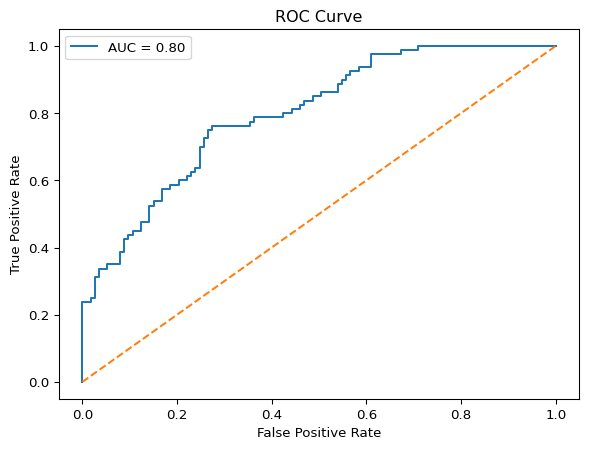

In [24]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y, y_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")  # random baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

### Task 4.1 — Understanding ROC

- What does the ROC curve represent?
- What are TPR and FPR?

## Solution

- ROC: trade-off between TPR and FPR across thresholds
- TPR = TP / (TP + FN)
- FPR = FP / (FP + TN)

Values for FPR, TPR at different thresholds:

In [25]:
roc_df = pd.DataFrame({"threshold": thresholds, "fpr": fpr, "tpr": tpr})

roc_df.head()

### Task 4.2 — Interpreting AUC

- What does the AUC value tell us?
- What would values near 0.5, 0.7, and 1.0 suggest?

## Solution

In [26]:
roc_auc

0.7982300884955752

- 0.5 → random
- ~0.7 → moderate
- 1.0 → perfect

### Task 4.3 — Threshold perspective

- Why is ROC/AUC useful when the company has not yet fixed one single
  decision threshold?

## Solution

- Evaluates performance across all thresholds
- Supports flexible decision-making
- Enables model comparison independent of cutoff



# Part 5 — Compare early-career urban borrowers and platform workers

Now repeat the same modeling steps the segment of platform workers.

### Task 5.1 — Fit the second model

Fit a logistic regression model for platform workers.

## Solution

In [29]:
df_B = df[df["customer_category"] == "platform_worker"]

y_B = df_B["default"]
X_B = df_B.drop(columns=["default", "customer_category"])

model_B = LogisticRegression()
model_B.fit(X_B, y_B)

/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(

### Task 5.2 — Compare coefficients

Compare the coefficients across both categories.

- Are the same predictors important in both groups?
- Does any variable appear to matter more strongly in one group than the
  other?

## Solution

In [31]:
coef_A = pd.Series(model.coef_[0], index=X.columns)
coef_B = pd.Series(model_B.coef_[0], index=X_B.columns)

comparison = pd.DataFrame({
    "Category_A": coef_A,
    "Category_B": coef_B
})

comparison

### Task 5.3 — Compare ROC and AUC

Compare the ROC curves and AUC values of the two models.

- Which category seems easier to classify?
- What might explain the difference?

## Solution

In [33]:
y_prob_B = model_B.predict_proba(X_B)[:, 1]

fpr_B, tpr_B, _ = roc_curve(y_B, y_prob_B)
roc_auc_B = auc(fpr_B, tpr_B)

roc_auc, roc_auc_B

(0.7982300884955752, 0.7174603174603175)

- Higher AUC → better ability to distinguish defaults from non-defaults



# 🧩 Wrap-up <a id="wrap-up"></a>

🎉🎈 You have completed the notebook – good work! 🎈🎉

In this notebook, we have learned to:

- Fit and interpret logistic regression models using `scikit-learn`
- Distinguish between predicted probabilities and class labels
- Apply and reflect on different classification thresholds
- Compute and interpret confusion-matrix-based metrics
- Understand ROC curves and AUC as threshold-independent evaluation
  tools
- Compare model performance across different customer categories
- Reflect on how model use depends on business context and risk strategy

> **Session 5 survey**
>
> Before you wrap up, please complete the Session 5 survey here:
> <a href="https://forms.gle/mVWw3z7ftFn48gDY6"
> target="_blank">https://forms.gle/mVWw3z7ftFn48gDY6</a>. Thank you 🙏